[← Back to Overview](./00_overview.ipynb) | [← Previous: PAM50 Subtypes](./03_pam50_subtype_analysis.ipynb)

# TCGA-BRCA Gene Expression Analysis (RNA-seq)

Comprehensive analysis of gene expression data including TPM, FPKM, FPKM-UQ, and raw counts.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.cluster import hierarchy
import warnings

# Import XenaCohort for easy data loading
from oncolearn.api.xenabrowser import XenaCohortBuilder

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

# Build the cohort
builder = XenaCohortBuilder()
cohort = builder.build_cohort("BRCA")

## Load Gene Expression Data

Using the `XenaCohort` class, we can load all mRNA sequencing data (TPM, FPKM, FPKM-UQ, counts).
We'll primarily focus on TPM (Transcripts Per Million) as it's normalized and suitable for comparison.

In [ ]:
# Load all mRNA expression data using XenaCohort
print("Loading mRNA expression data...")
mrna_all = cohort.mrna_seq()

print(f"All mRNA data shape: {mrna_all.shape}")
print(f"\nSource datasets:")
if '_source_dataset' in mrna_all.columns:
    for source in mrna_all['_source_dataset'].unique():
        count = (mrna_all['_source_dataset'] == source).sum()
        print(f"  - {source}: {count} rows")

# For this analysis, we'll focus on TPM data
# Filter for TPM data based on source dataset
tpm_data = mrna_all[mrna_all['_source_dataset'].str.contains('tpm', case=False, na=False)]

# Transpose to have genes as rows and samples as columns
# First column is typically the gene/feature identifier
if len(tpm_data) > 0:
    # Get sample columns (exclude _source_dataset)
    sample_cols = [col for col in tpm_data.columns if col != '_source_dataset']
    tpm = tpm_data[sample_cols].head(5000).set_index(sample_cols[0]) if len(sample_cols) > 0 else tpm_data.head(5000)
    
    # Convert to numeric
    tpm = tpm.apply(pd.to_numeric, errors='coerce')
    
    print(f"\nTPM data shape: {tpm.shape}")
    print(f"Number of genes: {tpm.shape[0]}")
    print(f"Number of samples: {tpm.shape[1]}")
    print(f"\nFirst few genes and samples:")
    display(tpm.iloc[:5, :5])
else:
    print("⚠ TPM data not found in the loaded datasets")

Loading TPM gene expression data...
TPM data shape: (5000, 1226)
Number of genes: 5000
Number of samples: 1226

First few genes and samples:


,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B
Ensembl_ID,,,,,
ENSG00000000003.15,5.662037,3.703721,6.514515,4.784917,4.251984
ENSG00000000005.6,3.376096,0.463099,0.000000,2.328061,0.435415
ENSG00000000419.13,6.860140,7.086452,6.805072,6.443071,6.178436
ENSG00000000457.14,4.400552,4.051007,5.037264,4.374970,3.558464
ENSG00000000460.17,2.845169,2.426989,4.043248,4.162790,2.589548


In [3]:
# Data quality checks
print("\nData Quality Checks:")
print(f"Missing values: {tpm.isna().sum().sum()}")
print(
    f"Zero values: {(tpm == 0).sum().sum()} ({((tpm == 0).sum().sum() / tpm.size) * 100:.1f}%)")
print(f"Negative values: {(tpm < 0).sum().sum()}")

# Basic statistics
print(f"\nExpression range: {tpm.min().min():.2f} to {tpm.max().max():.2f}")
print(f"Mean expression: {tpm.mean().mean():.2f}")
print(f"Median expression: {tpm.median().median():.2f}")


Data Quality Checks:
Missing values: 0
Zero values: 244806 (4.0%)
Negative values: 0

Expression range: 0.00 to 17.09
Mean expression: 3.73
Median expression: 4.04


## Sample-Level Analysis

Sample-level statistics:
Mean expression per sample - Range: 2.21 to 4.17
Median genes detected: 4806 (96.1%)


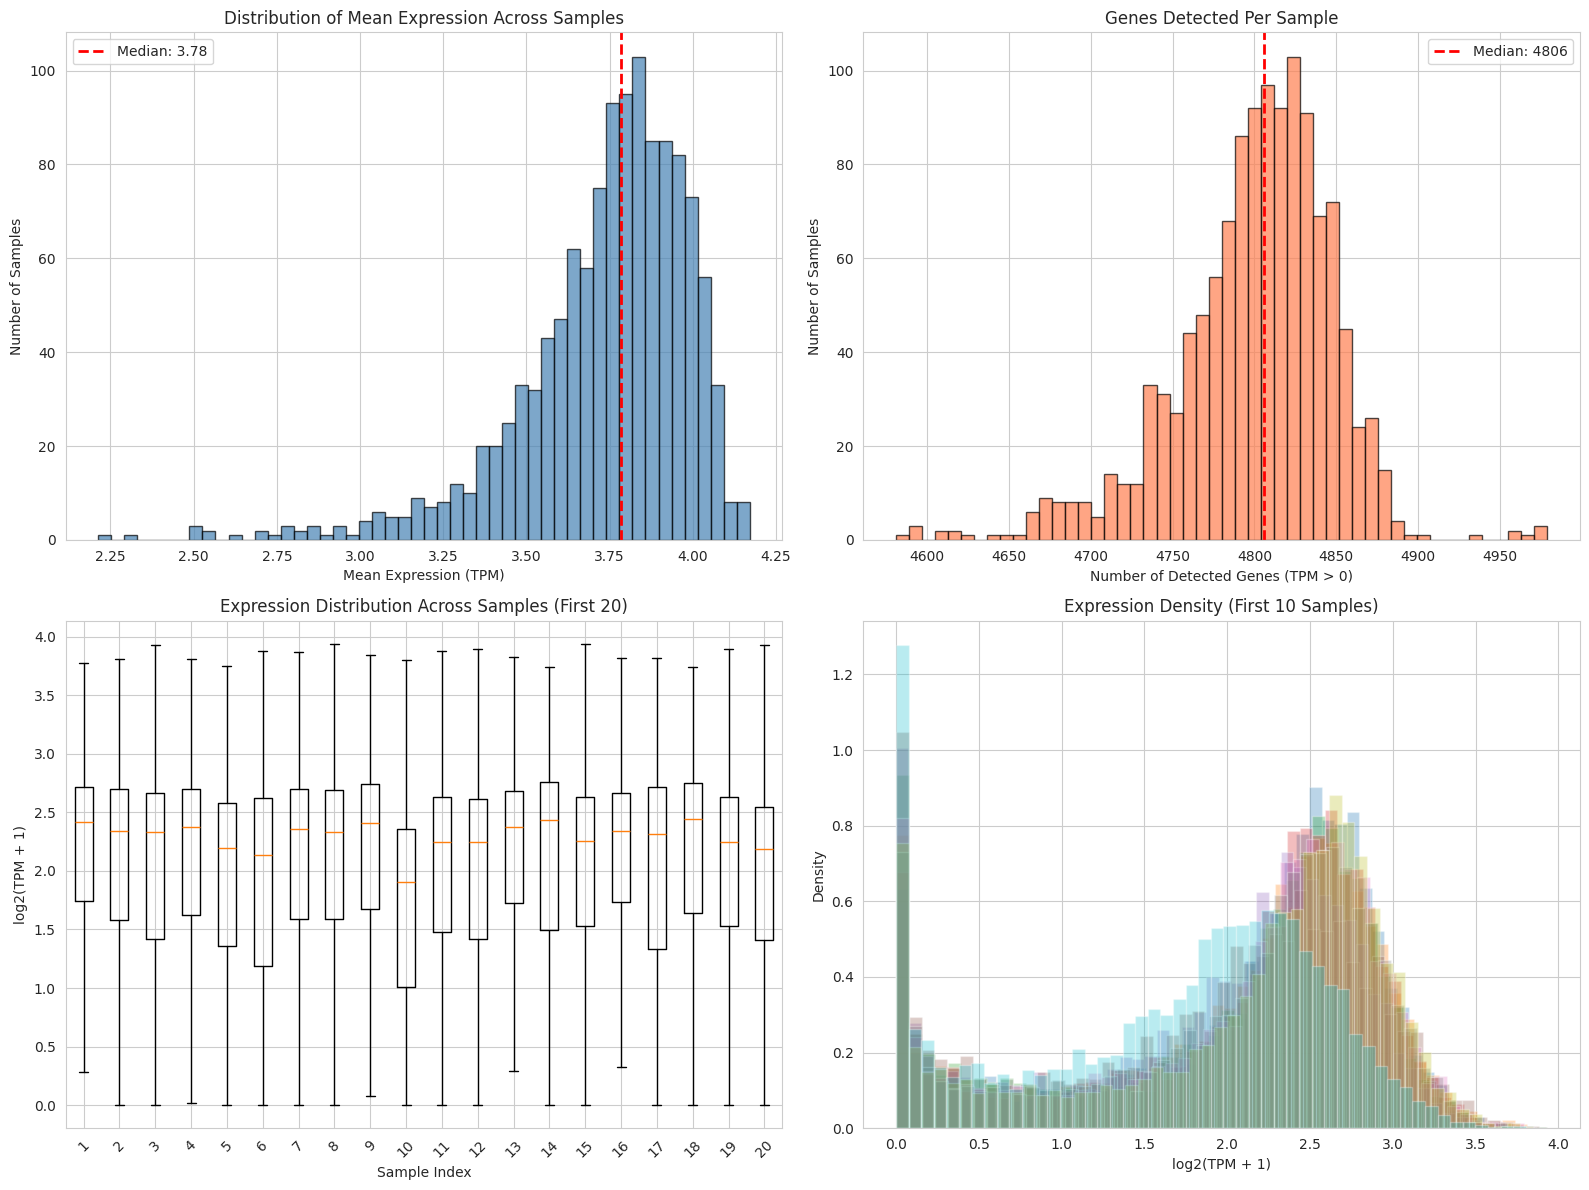

In [4]:
# Per-sample statistics
sample_means = tpm.mean(axis=0)
sample_medians = tpm.median(axis=0)
sample_detected = (tpm > 0).sum(axis=0)  # Number of detected genes

print("Sample-level statistics:")
print(
    f"Mean expression per sample - Range: {sample_means.min():.2f} to {sample_means.max():.2f}")
print(
    f"Median genes detected: {sample_detected.median():.0f} ({sample_detected.median()/len(tpm)*100:.1f}%)")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution of mean expression per sample
axes[0, 0].hist(sample_means, bins=50, color='steelblue',
                alpha=0.7, edgecolor='black')
axes[0, 0].axvline(sample_means.median(), color='red', linestyle='--', linewidth=2,
                   label=f'Median: {sample_means.median():.2f}')
axes[0, 0].set_xlabel('Mean Expression (TPM)')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_title('Distribution of Mean Expression Across Samples')
axes[0, 0].legend()

# Number of detected genes per sample
axes[0, 1].hist(sample_detected, bins=50, color='coral',
                alpha=0.7, edgecolor='black')
axes[0, 1].axvline(sample_detected.median(), color='red', linestyle='--', linewidth=2,
                   label=f'Median: {sample_detected.median():.0f}')
axes[0, 1].set_xlabel('Number of Detected Genes (TPM > 0)')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_title('Genes Detected Per Sample')
axes[0, 1].legend()

# Sample boxplot (first 50 samples)
sample_subset = tpm.iloc[:, :50]
log_subset = np.log2(sample_subset + 1)
axes[1, 0].boxplot([log_subset.iloc[:, i].values for i in range(min(20, log_subset.shape[1]))],
                   showfliers=False)
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('log2(TPM + 1)')
axes[1, 0].set_title('Expression Distribution Across Samples (First 20)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Density plot
for i in range(min(10, tpm.shape[1])):
    sample_data = np.log2(tpm.iloc[:, i] + 1)
    axes[1, 1].hist(sample_data, bins=50, alpha=0.3, density=True)
axes[1, 1].set_xlabel('log2(TPM + 1)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Expression Density (First 10 Samples)')

plt.tight_layout()
plt.show()

## Gene-Level Analysis

In [5]:
# Per-gene statistics
gene_means = tpm.mean(axis=1)
gene_medians = tpm.median(axis=1)
gene_stds = tpm.std(axis=1)
gene_vars = tpm.var(axis=1)
gene_cv = gene_stds / (gene_means + 0.01)  # Coefficient of variation
# Number of samples where gene is detected
gene_detected = (tpm > 0).sum(axis=1)

print("Gene-level statistics:")
print(
    f"Mean expression per gene: {gene_means.mean():.2f} ± {gene_means.std():.2f}")
print(
    f"Median genes expressed in samples: {gene_detected.median():.0f} ({gene_detected.median()/tpm.shape[1]*100:.1f}%)")
print(
    f"\nGenes detected in >50% samples: {(gene_detected > tpm.shape[1]/2).sum()} ({(gene_detected > tpm.shape[1]/2).sum()/len(tpm)*100:.1f}%)")
print(
    f"Genes detected in >90% samples: {(gene_detected > tpm.shape[1]*0.9).sum()} ({(gene_detected > tpm.shape[1]*0.9).sum()/len(tpm)*100:.1f}%)")

Gene-level statistics:
Mean expression per gene: 3.73 ± 2.16
Median genes expressed in samples: 1226 (100.0%)

Genes detected in >50% samples: 4833 (96.7%)
Genes detected in >90% samples: 4592 (91.8%)


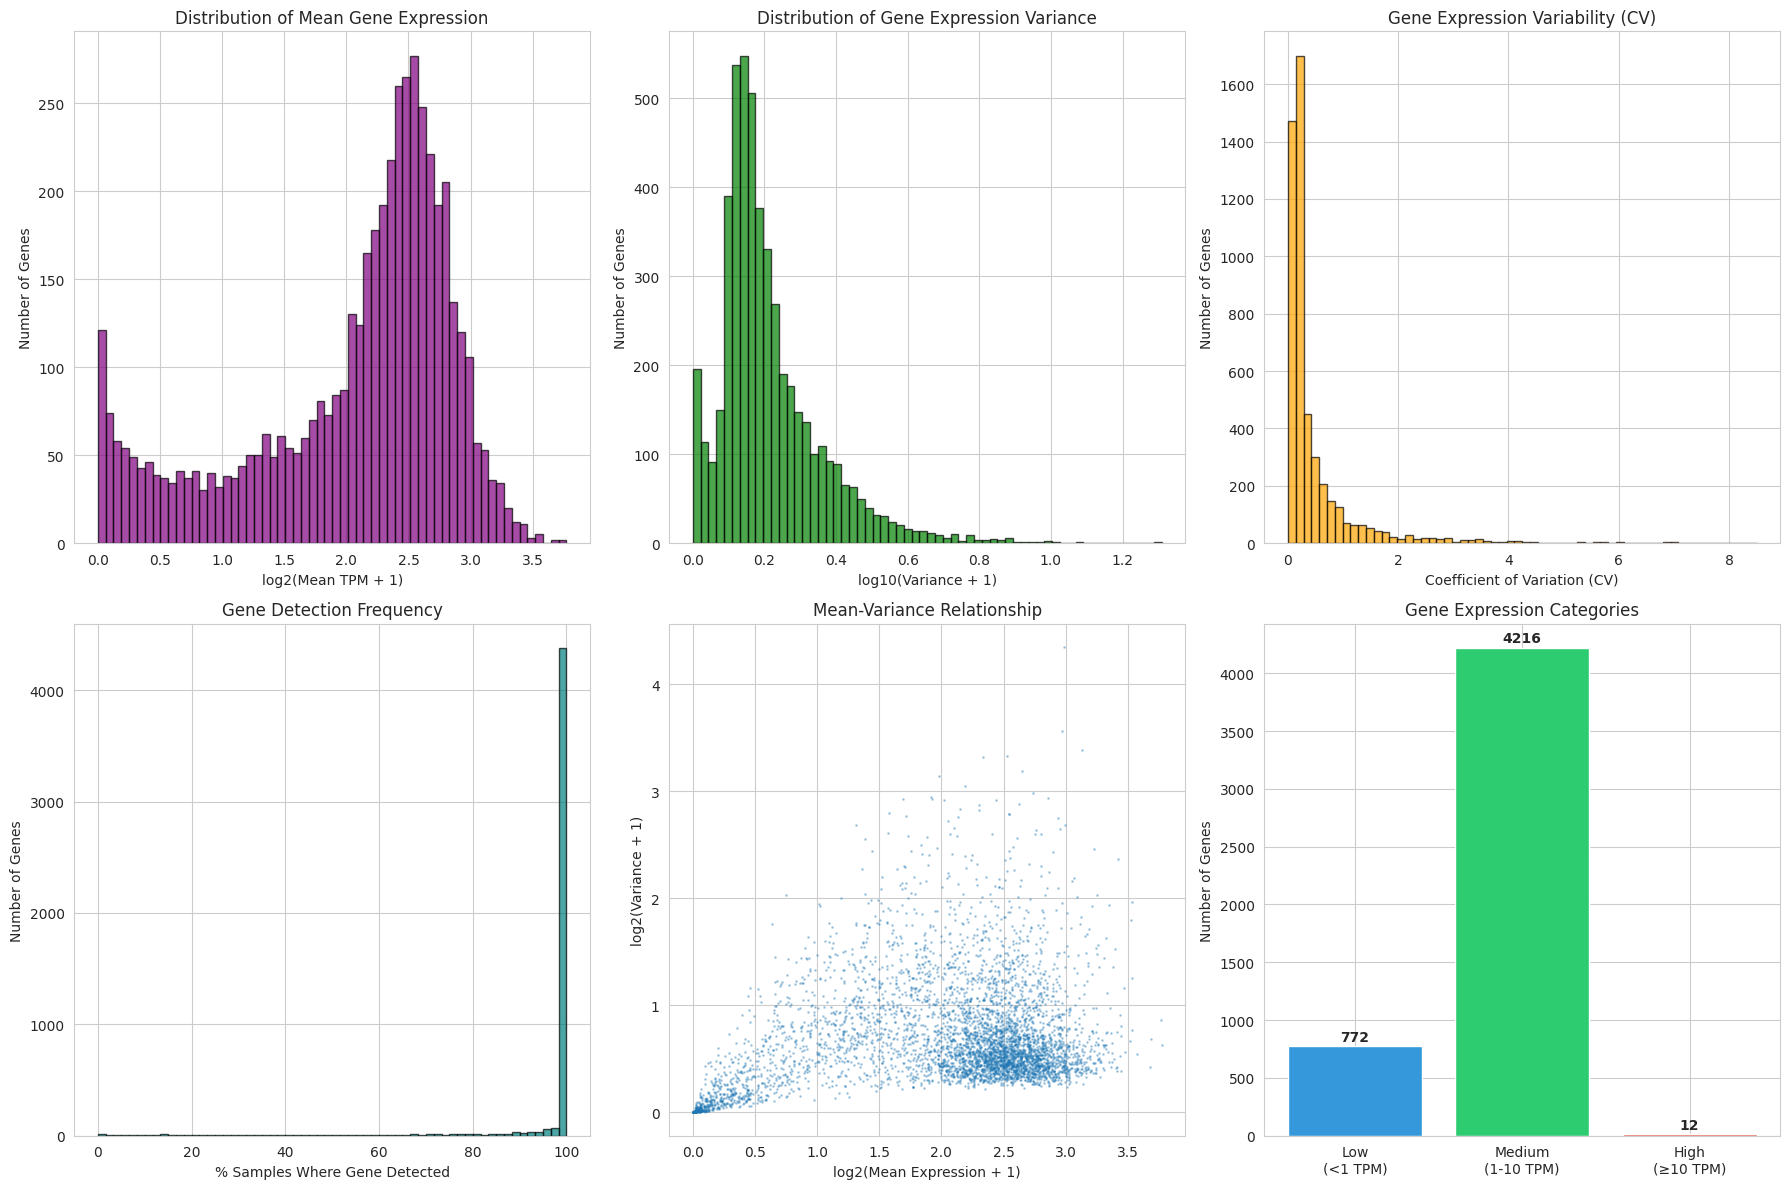

In [6]:
# Visualize gene-level statistics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Mean expression distribution
axes[0, 0].hist(np.log2(gene_means + 1), bins=60,
                color='purple', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('log2(Mean TPM + 1)')
axes[0, 0].set_ylabel('Number of Genes')
axes[0, 0].set_title('Distribution of Mean Gene Expression')

# Variance distribution
axes[0, 1].hist(np.log10(gene_vars + 1), bins=60,
                color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('log10(Variance + 1)')
axes[0, 1].set_ylabel('Number of Genes')
axes[0, 1].set_title('Distribution of Gene Expression Variance')

# Coefficient of variation
axes[0, 2].hist(gene_cv[gene_cv < 10], bins=60,
                color='orange', alpha=0.7, edgecolor='black')
axes[0, 2].set_xlabel('Coefficient of Variation (CV)')
axes[0, 2].set_ylabel('Number of Genes')
axes[0, 2].set_title('Gene Expression Variability (CV)')

# Detection frequency
axes[1, 0].hist(gene_detected / tpm.shape[1] * 100, bins=60,
                color='teal', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('% Samples Where Gene Detected')
axes[1, 0].set_ylabel('Number of Genes')
axes[1, 0].set_title('Gene Detection Frequency')

# Mean-variance relationship
axes[1, 1].scatter(np.log2(gene_means + 1),
                   np.log2(gene_vars + 1), alpha=0.3, s=1)
axes[1, 1].set_xlabel('log2(Mean Expression + 1)')
axes[1, 1].set_ylabel('log2(Variance + 1)')
axes[1, 1].set_title('Mean-Variance Relationship')

# Expression categories
low_expr = (gene_means < 1).sum()
med_expr = ((gene_means >= 1) & (gene_means < 10)).sum()
high_expr = (gene_means >= 10).sum()
categories = ['Low\n(<1 TPM)', 'Medium\n(1-10 TPM)', 'High\n(≥10 TPM)']
counts = [low_expr, med_expr, high_expr]
axes[1, 2].bar(categories, counts, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1, 2].set_ylabel('Number of Genes')
axes[1, 2].set_title('Gene Expression Categories')
for i, v in enumerate(counts):
    axes[1, 2].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Highly Expressed Genes

Top 30 Highly Expressed Genes:
 1. ENSG00000087086.15            :      12.66 TPM
 2. ENSG00000034510.6             :      12.59 TPM
 3. ENSG00000112306.8             :      11.87 TPM
 4. ENSG00000075624.17            :      11.81 TPM
 5. ENSG00000096384.20            :      10.90 TPM
 6. ENSG00000111640.15            :      10.60 TPM
 7. ENSG00000108821.14            :      10.60 TPM
 8. ENSG00000113140.11            :      10.57 TPM
 9. ENSG00000100219.16            :      10.55 TPM
10. ENSG00000100316.16            :      10.44 TPM
11. ENSG00000089157.16            :      10.17 TPM
12. ENSG00000019582.15            :      10.10 TPM
13. ENSG00000108298.12            :       9.90 TPM
14. ENSG00000080824.19            :       9.89 TPM
15. ENSG00000068697.7             :       9.87 TPM
16. ENSG00000100097.12            :       9.83 TPM
17. ENSG00000118181.11            :       9.81 TPM
18. ENSG00000111341.10            :       9.72 TPM
19. ENSG00000109971.14            :       9.67 TPM


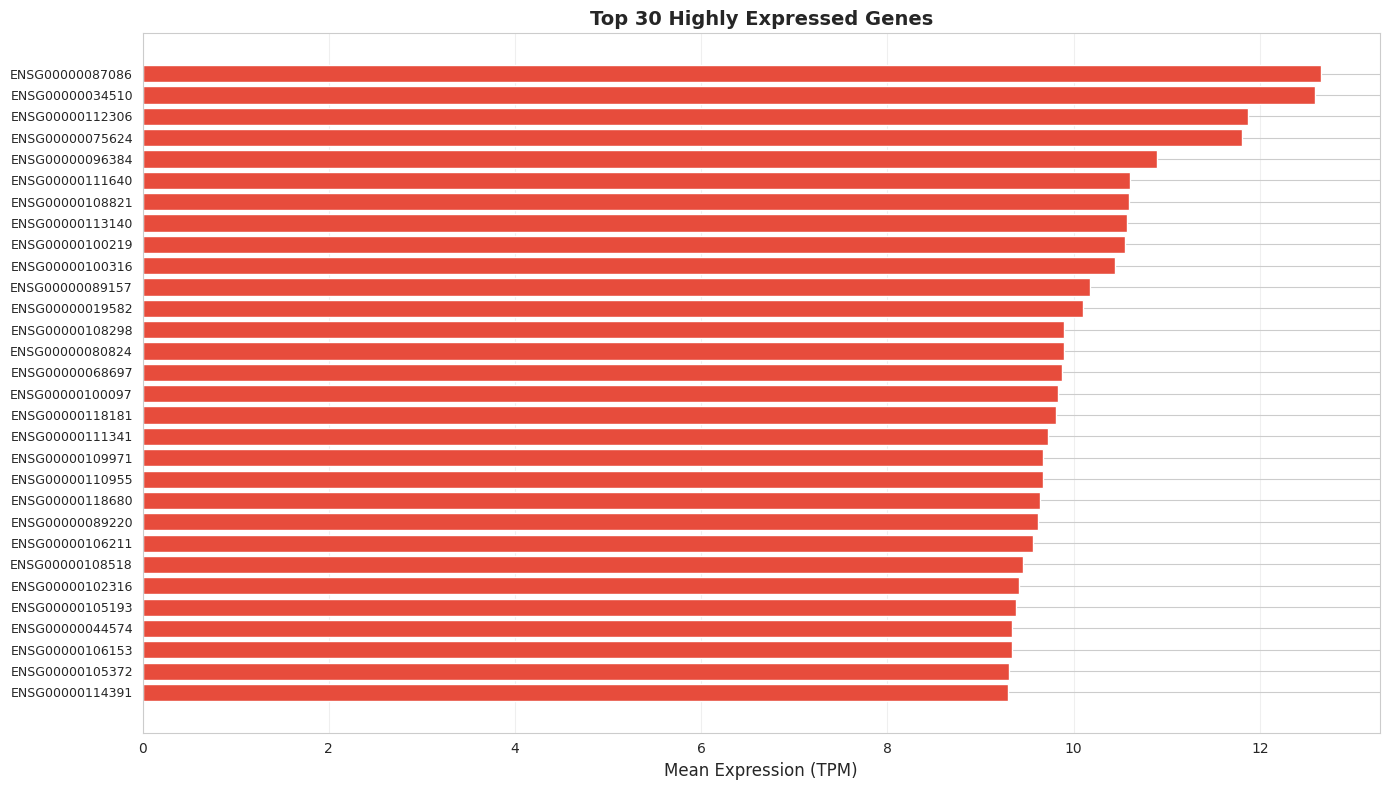

In [7]:
# Top expressed genes
top_genes = gene_means.nlargest(30)

print("Top 30 Highly Expressed Genes:")
for i, (gene, expr) in enumerate(top_genes.items(), 1):
    print(f"{i:2d}. {gene:30s}: {expr:10.2f} TPM")

# Visualize
plt.figure(figsize=(14, 8))
plt.barh(range(len(top_genes)), top_genes.values, color='#e74c3c')
plt.yticks(range(len(top_genes)), [g.split('.')[0]
           for g in top_genes.index], fontsize=9)
plt.xlabel('Mean Expression (TPM)', fontsize=12)
plt.title('Top 30 Highly Expressed Genes', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Variable Genes

Top 30 Most Variable Genes:
 1. ENSG00000110484.7             : Var=     19.37, Mean=    6.93, CV=  0.63
 2. ENSG00000012223.13            : Var=     10.82, Mean=    6.86, CV=  0.48
 3. ENSG00000106541.12            : Var=      9.45, Mean=    7.78, CV=  0.39
 4. ENSG00000086548.9             : Var=      9.05, Mean=    4.78, CV=  0.63
 5. ENSG00000094755.17            : Var=      8.98, Mean=    4.05, CV=  0.74
 6. ENSG00000104332.12            : Var=      8.13, Mean=    5.27, CV=  0.54
 7. ENSG00000100867.15            : Var=      7.81, Mean=    2.94, CV=  0.95
 8. ENSG00000008196.13            : Var=      7.26, Mean=    3.56, CV=  0.75
 9. ENSG00000091831.24            : Var=      6.94, Mean=    5.66, CV=  0.46
10. ENSG00000100146.18            : Var=      6.71, Mean=    2.77, CV=  0.93
11. ENSG00000101443.18            : Var=      6.66, Mean=    6.27, CV=  0.41
12. ENSG00000100362.13            : Var=      6.63, Mean=    2.22, CV=  1.15
13. ENSG00000105388.16            : Var=      6.

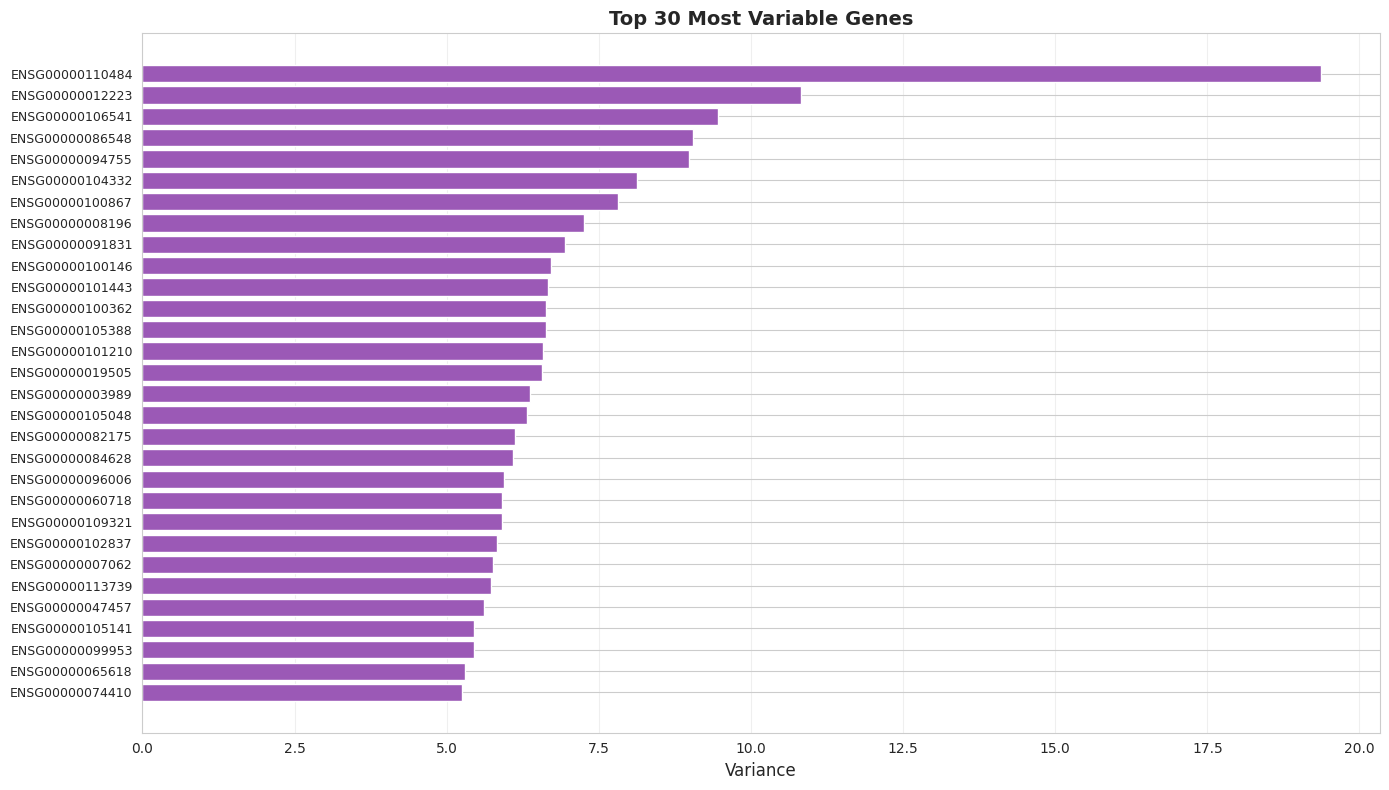

In [8]:
# Most variable genes
top_var_genes = gene_vars.nlargest(30)

print("Top 30 Most Variable Genes:")
for i, (gene, var) in enumerate(top_var_genes.items(), 1):
    mean = gene_means[gene]
    cv = gene_cv[gene]
    print(f"{i:2d}. {gene:30s}: Var={var:10.2f}, Mean={mean:8.2f}, CV={cv:6.2f}")

# Visualize
plt.figure(figsize=(14, 8))
plt.barh(range(len(top_var_genes)), top_var_genes.values, color='#9b59b6')
plt.yticks(range(len(top_var_genes)), [g.split('.')[
           0] for g in top_var_genes.index], fontsize=9)
plt.xlabel('Variance', fontsize=12)
plt.title('Top 30 Most Variable Genes', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Expression Heatmap

Generating heatmap of top variable genes...


<Figure size 1600x1400 with 0 Axes>

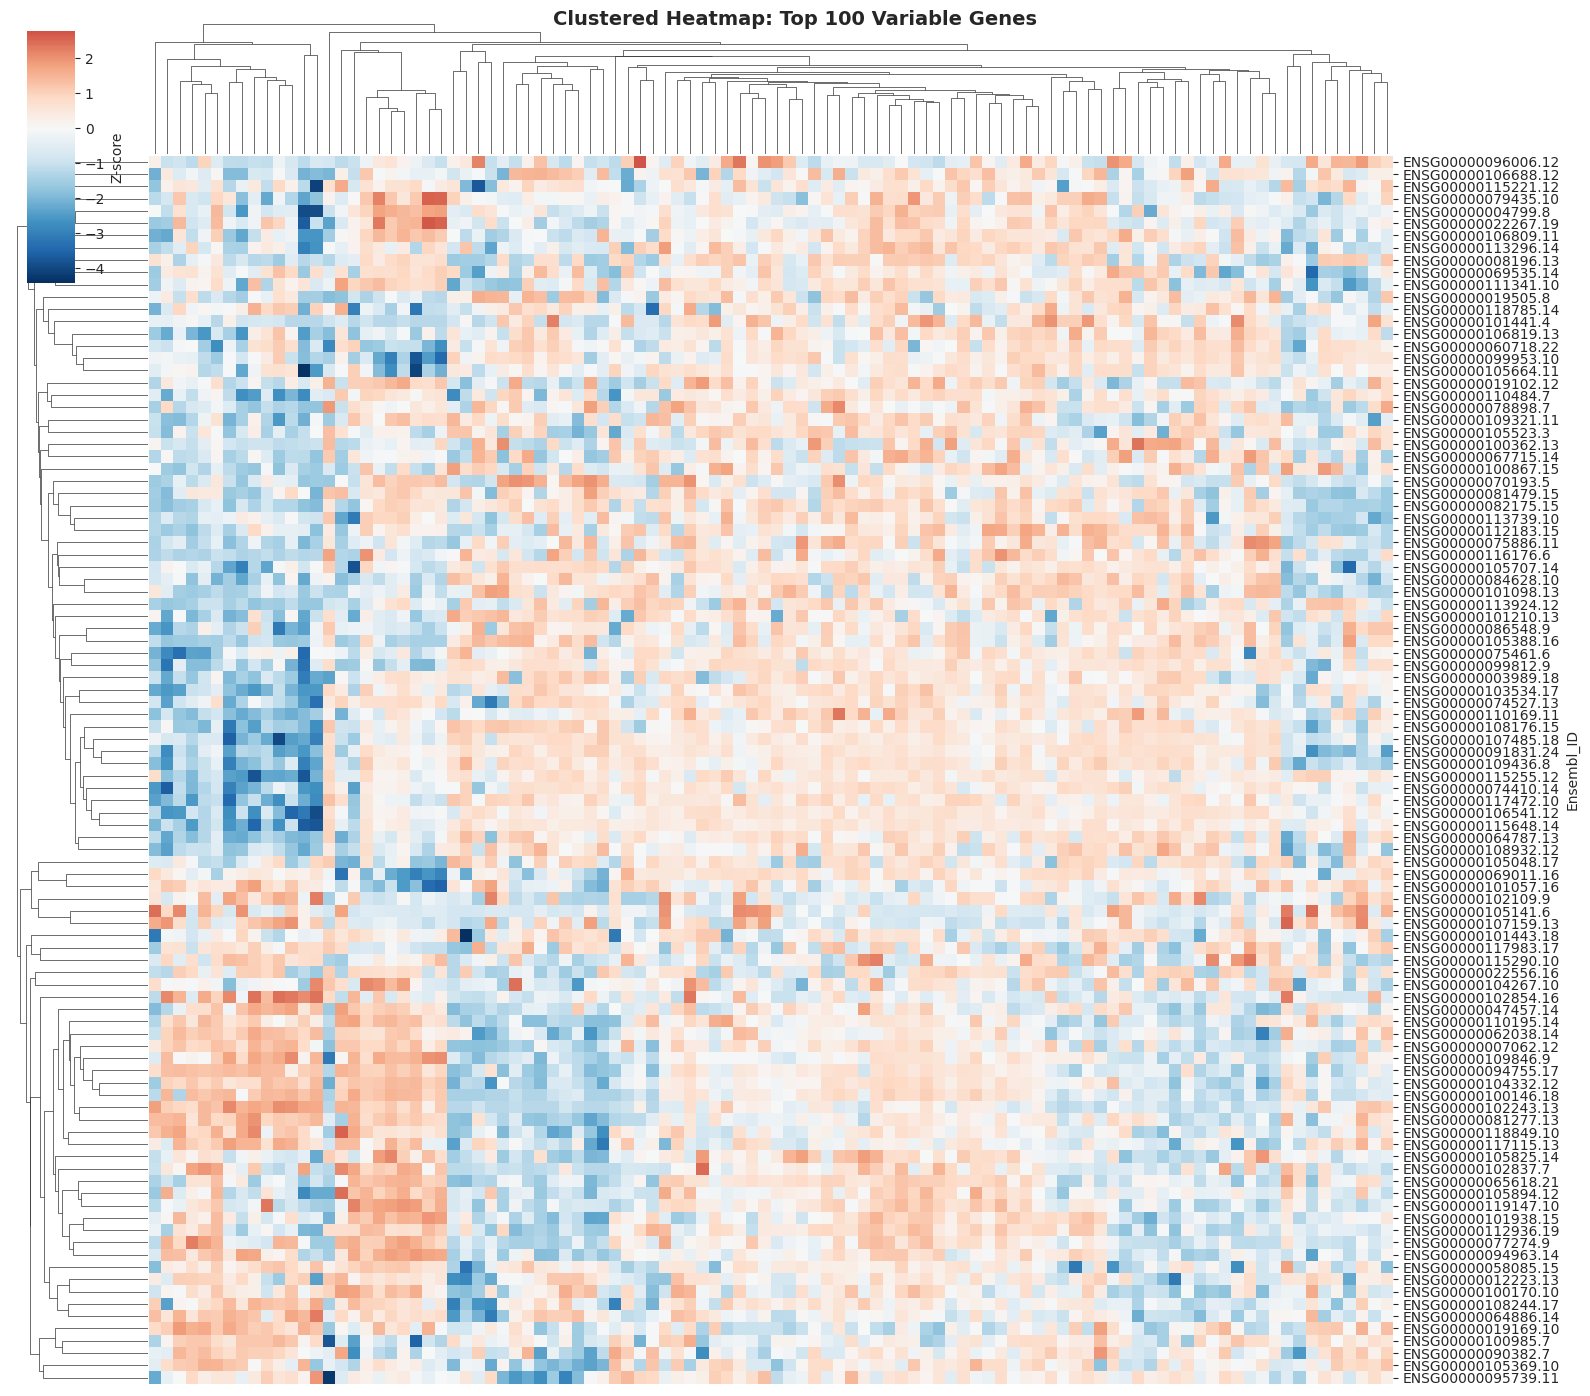

In [9]:
# Heatmap of top variable genes
print("Generating heatmap of top variable genes...")

# Select top 100 variable genes
top_100_var = gene_vars.nlargest(100).index

# Sample subset for visualization
sample_subset = tpm.columns[::5][:100]  # Every 5th sample, max 100
heatmap_data = tpm.loc[top_100_var, sample_subset]

# Log transform and Z-score normalization
heatmap_log = np.log2(heatmap_data + 1)
heatmap_zscore = (heatmap_log.T - heatmap_log.mean(axis=1)) / \
    heatmap_log.std(axis=1)
heatmap_zscore = heatmap_zscore.T

# Cluster
plt.figure(figsize=(16, 14))
sns.clustermap(heatmap_zscore, cmap='RdBu_r', center=0,
               xticklabels=False, yticklabels=True,
               figsize=(16, 14), cbar_kws={'label': 'Z-score'},
               dendrogram_ratio=0.1, cbar_pos=(0.02, 0.8, 0.03, 0.18))
plt.suptitle('Clustered Heatmap: Top 100 Variable Genes',
             y=0.995, fontsize=14, fontweight='bold')
plt.show()

## Sample Correlation

Calculating sample correlations (using subset of genes)...


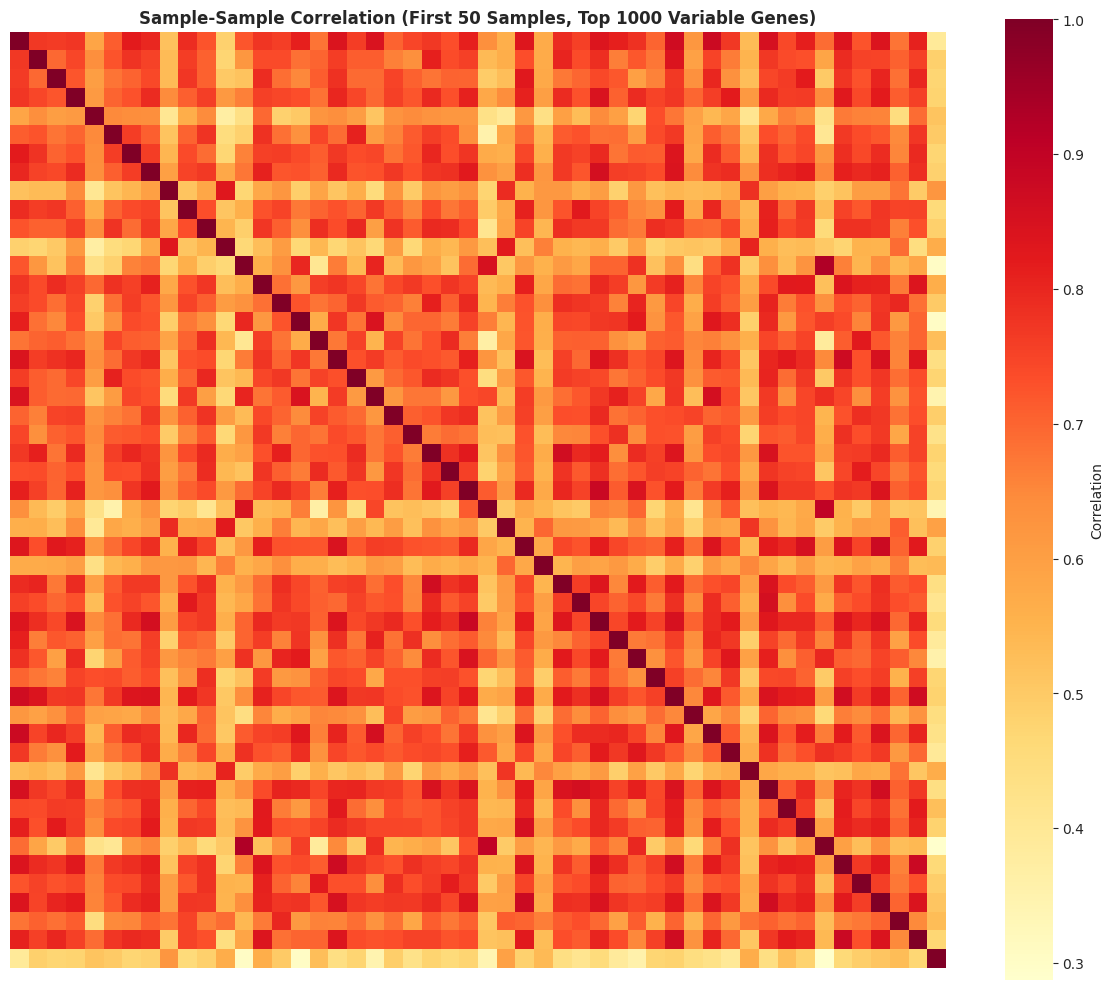


Mean correlation: 0.676
Median correlation: 0.704


In [10]:
# Calculate sample-sample correlation
print("Calculating sample correlations (using subset of genes)...")

# Use top variable genes for correlation
top_1000_var = gene_vars.nlargest(1000).index
expr_subset = tpm.loc[top_1000_var]

# Sample subset for visualization
sample_corr_subset = expr_subset.iloc[:, :50]  # First 50 samples
sample_corr = sample_corr_subset.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(sample_corr, cmap='YlOrRd', square=True,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Correlation'})
plt.title('Sample-Sample Correlation (First 50 Samples, Top 1000 Variable Genes)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(
    f"\nMean correlation: {sample_corr.values[np.triu_indices_from(sample_corr.values, k=1)].mean():.3f}")
print(
    f"Median correlation: {np.median(sample_corr.values[np.triu_indices_from(sample_corr.values, k=1)]):.3f}")

## Summary

In [11]:
print("\n" + "="*70)
print("TCGA-BRCA Gene Expression (RNA-seq) Summary")
print("="*70)
print(f"Total genes analyzed: {len(tpm)}")
print(f"Total samples: {tpm.shape[1]}")
print(f"\nExpression Statistics:")
print(f"  Mean expression: {gene_means.mean():.2f} TPM")
print(f"  Median expression: {gene_medians.median():.2f} TPM")
print(
    f"  Highly expressed genes (>10 TPM): {high_expr} ({high_expr/len(tpm)*100:.1f}%)")
print(
    f"  Genes detected in >50% samples: {(gene_detected > tpm.shape[1]/2).sum()}")
print(f"\nTop 5 expressed genes:")
for gene, expr in gene_means.nlargest(5).items():
    print(f"  {gene.split('.')[0]:20s}: {expr:.2f} TPM")
print("="*70)


TCGA-BRCA Gene Expression (RNA-seq) Summary
Total genes analyzed: 5000
Total samples: 1226

Expression Statistics:
  Mean expression: 3.73 TPM
  Median expression: 4.03 TPM
  Highly expressed genes (>10 TPM): 12 (0.2%)
  Genes detected in >50% samples: 4833

Top 5 expressed genes:
  ENSG00000087086     : 12.66 TPM
  ENSG00000034510     : 12.59 TPM
  ENSG00000112306     : 11.87 TPM
  ENSG00000075624     : 11.81 TPM
  ENSG00000096384     : 10.90 TPM
